
Запуск теста Энгла-Грэнджера для 40 переменных...


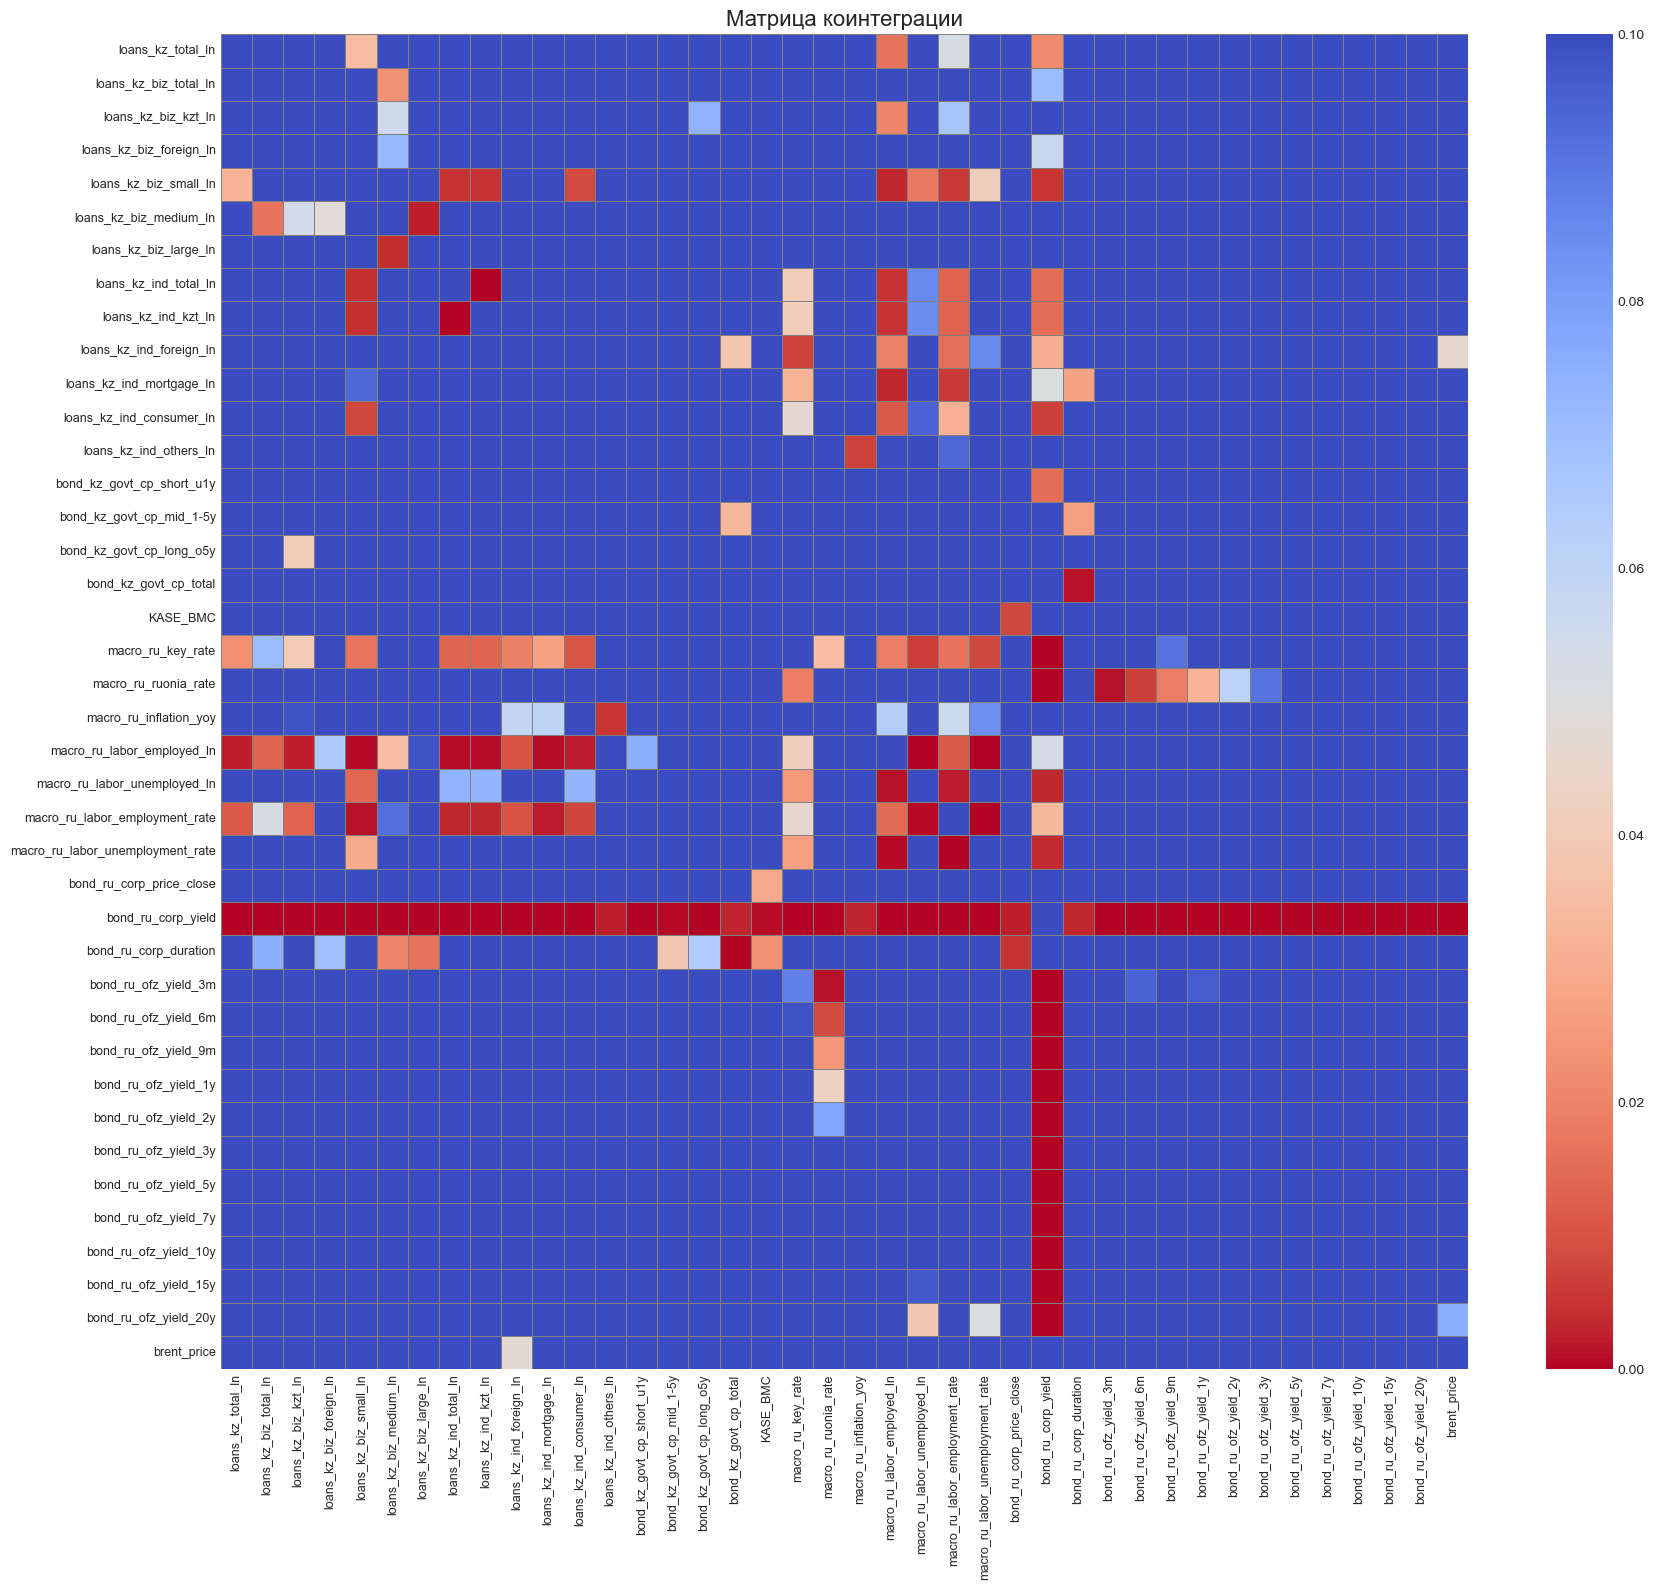


--- Проверка ключевых связей (p-value < 0.05) ---
loans_kz_total_ln <---> macro_ru_labor_employed_ln | p-value: 0.0168
loans_kz_total_ln <---> bond_ru_corp_yield | p-value: 0.0218
loans_kz_biz_kzt_ln <---> macro_ru_labor_employed_ln | p-value: 0.0205
loans_kz_biz_small_ln <---> macro_ru_labor_employed_ln | p-value: 0.0032
loans_kz_biz_small_ln <---> macro_ru_labor_unemployed_ln | p-value: 0.0178
loans_kz_biz_small_ln <---> macro_ru_labor_employment_rate | p-value: 0.0058
loans_kz_biz_small_ln <---> macro_ru_labor_unemployment_rate | p-value: 0.0415
loans_kz_biz_small_ln <---> bond_ru_corp_yield | p-value: 0.0054
loans_kz_ind_total_ln <---> macro_ru_key_rate | p-value: 0.0412
loans_kz_ind_total_ln <---> macro_ru_labor_employed_ln | p-value: 0.0050
loans_kz_ind_total_ln <---> macro_ru_labor_employment_rate | p-value: 0.0132
loans_kz_ind_total_ln <---> bond_ru_corp_yield | p-value: 0.0155
loans_kz_ind_kzt_ln <---> macro_ru_key_rate | p-value: 0.0408
loans_kz_ind_kzt_ln <---> macro_ru_lab

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import coint
import warnings
from Метрики.read_functions import dict_func

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

all_dfs = []
for path, func in dict_func.items():
    try:
        temp_df = func(f'Метрики/{path}')
        temp_df['date'] = pd.to_datetime(temp_df['date'])
        temp_df = temp_df.drop_duplicates(subset=['date'])
        all_dfs.append(temp_df.set_index('date'))
    except: 
        pass

df_raw = pd.concat(all_dfs, axis=1)
df_raw = df_raw.resample('D').mean()
df_raw = df_raw.interpolate(method='time') 
df_raw = df_raw.ffill().bfill()
df_raw = df_raw.loc['2022-01-01':'2026-01-01']

cols_to_log = [
    'loans_kz_total', 'loans_kz_biz_total', 'loans_kz_biz_kzt', 'loans_kz_biz_foreign',
    'loans_kz_biz_small', 'loans_kz_biz_medium', 'loans_kz_biz_large', 'loans_kz_ind_total',
    'loans_kz_ind_kzt', 'loans_kz_ind_foreign', 'loans_kz_ind_mortgage', 'loans_kz_ind_consumer',
    'loans_kz_ind_others', 
    'macro_ru_labor_employed', 'macro_ru_labor_unemployed',
]

for col in cols_to_log:
    if col in df_raw.columns:
        df_raw[f"{col}_ln"] = np.log(df_raw[col].replace(0, np.nan).ffill())


all_i1_cols = [
    # Кредиты
    'loans_kz_total_ln', 'loans_kz_biz_total_ln', 'loans_kz_biz_kzt_ln', 'loans_kz_biz_foreign_ln',
    'loans_kz_biz_small_ln', 'loans_kz_biz_medium_ln', 'loans_kz_biz_large_ln', 'loans_kz_ind_total_ln',
    'loans_kz_ind_kzt_ln', 'loans_kz_ind_foreign_ln', 'loans_kz_ind_mortgage_ln', 'loans_kz_ind_consumer_ln',
    'loans_kz_ind_others_ln',
    # Индексы РК
    'bond_kz_govt_cp_short_u1y', 'bond_kz_govt_cp_mid_1-5y', 'bond_kz_govt_cp_long_o5y',
    'bond_kz_govt_cp_total', 'KASE_BMC',
    # Макро РФ
    'macro_ru_key_rate', 'macro_ru_ruonia_rate', 'macro_ru_inflation_yoy',
    'macro_ru_labor_employed_ln', 'macro_ru_labor_unemployed_ln', 
    'macro_ru_labor_employment_rate', 'macro_ru_labor_unemployment_rate',
    # Корп РФ
    'bond_ru_corp_price_close', 'bond_ru_corp_yield', 'bond_ru_corp_duration',
    # Кривая ОФЗ
    'bond_ru_ofz_yield_3m', 'bond_ru_ofz_yield_6m', 'bond_ru_ofz_yield_9m', 'bond_ru_ofz_yield_1y',
    'bond_ru_ofz_yield_2y', 'bond_ru_ofz_yield_3y', 'bond_ru_ofz_yield_5y', 'bond_ru_ofz_yield_7y',
    'bond_ru_ofz_yield_10y', 'bond_ru_ofz_yield_15y', 'bond_ru_ofz_yield_20y',
    # Сырье (Ln)
    'brent_price'
]

df_full_i1 = df_raw[all_i1_cols].dropna()

print(f"\nЗапуск теста Энгла-Грэнджера для {len(all_i1_cols)} переменных...")
n = len(all_i1_cols)
p_value_matrix = np.ones((n, n))
for i in range(n):
    for j in range(n):
        if i != j:
            _, p_value, _ = coint(df_full_i1[all_i1_cols[i]], df_full_i1[all_i1_cols[j]], maxlag=5)
            p_value_matrix[i, j] = p_value

plt.figure(figsize=(18, 16), dpi=100)
sns.heatmap(pd.DataFrame(p_value_matrix, index=all_i1_cols, columns=all_i1_cols), 
            annot=False, cmap='coolwarm_r', vmin=0, vmax=0.10, linewidths=0.5, linecolor='gray')
plt.title("Матрица коинтеграции", fontsize=16)
plt.xticks(rotation=90, fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

print("\n--- Проверка ключевых связей (p-value < 0.05) ---")
for i in range(n):
    for j in range(i+1, n):
        p_val = p_value_matrix[i, j]
        col1, col2 = all_i1_cols[i], all_i1_cols[j]
        if p_val < 0.05 and ('ru' in col1 or 'brent' in col1 or 'brent' in col2 or 'ru' in col2):
            print(f"{col1} <---> {col2} | p-value: {p_val:.4f}")

In [52]:
from statsmodels.tsa.vector_ar.vecm import select_order, coint_johansen, VECM
import warnings
from Метрики.read_functions import dict_func

ofz_core = [
    'bond_ru_ofz_yield_3m', 
    'bond_ru_ofz_yield_9m', 
    'bond_ru_ofz_yield_2y', 
    'bond_ru_ofz_yield_5y', 
    'bond_ru_ofz_yield_15y'
]

macro_anchors = [
    'bond_ru_corp_yield',
    'brent_price',
    'macro_ru_key_rate',
    'KASE_BMC',
    'macro_ru_ruonia_rate',
    'bond_kz_govt_cp_short_u1y',
    'loans_kz_total_ln'
]

vecm_cols = ofz_core + macro_anchors
df_vecm_slim = df_raw[vecm_cols].dropna()

print(f"Размерность данных для VECM: {df_vecm_slim.shape}")

print("\n--- Тест Йохансена для 12 переменных ---")
lag_order_slim = select_order(df_vecm_slim, maxlags=3, deterministic="ci")
opt_lag_slim = lag_order_slim.aic
print(f"Оптимальный лаг (AIC): {opt_lag_slim}")

johansen_slim = coint_johansen(df_vecm_slim, det_order=1, k_ar_diff=opt_lag_slim)
print("Тест Йохансена прошел успешно. Ищем ранг коинтеграции (r):")

cointegration_rank = 0
for i in range(len(johansen_slim.lr1)):
    trace_stat = johansen_slim.lr1[i]
    crit_val_95 = johansen_slim.cvt[i, 1]
    
    if trace_stat > crit_val_95:
         cointegration_rank = i + 1
    else:
        print(f"Ранг r <= {i} : Trace Stat = {trace_stat:.2f} , Crit(95%) = {crit_val_95:.2f} -> НЕ ОТВЕРГАЕМ H0")
        break
        
print(f"Выбранный ранг коинтеграции: {cointegration_rank}")

Размерность данных для VECM: (1462, 12)

--- Тест Йохансена для 12 переменных ---
Оптимальный лаг (AIC): 2
Тест Йохансена прошел успешно. Ищем ранг коинтеграции (r):
Ранг r <= 5 : Trace Stat = 136.75 , Crit(95%) = 139.28 -> НЕ ОТВЕРГАЕМ H0
Выбранный ранг коинтеграции: 5


In [53]:
import joblib
import numpy as np
import pandas as pd
from statsmodels.tsa.vector_ar.vecm import VECM

ofz_core = [
    'bond_ru_ofz_yield_3m', 'bond_ru_ofz_yield_9m', 'bond_ru_ofz_yield_2y', 
    'bond_ru_ofz_yield_5y', 'bond_ru_ofz_yield_15y'
]
macro_anchors = [
    'bond_ru_corp_yield', 'brent_price', 'macro_ru_key_rate', 'KASE_BMC', 
    'macro_ru_ruonia_rate', 'bond_kz_govt_cp_short_u1y', 'loans_kz_total_ln'
]
vecm_cols = ofz_core + macro_anchors
df_vecm_slim = df_raw[vecm_cols].dropna()

# Гиперпараметры из теста Йохансена
opt_lag_slim = 2
coint_rank_use = 5

# Подготовка к Walk-Forward
train_end = pd.to_datetime('2025-11-30')
history_df = df_vecm_slim.loc[:train_end].copy()
test_df = df_vecm_slim.loc['2025-12-01':'2025-12-31']

predictions = []
actuals = []

print(f"Запуск Walk-Forward Validation (1 день вперед). Ранг коинтеграции: {coint_rank_use}...")

for date, row in test_df.iterrows():
    vecm_model = VECM(history_df, k_ar_diff=opt_lag_slim, coint_rank=coint_rank_use, deterministic="ci")
    try:
        vecm_res = vecm_model.fit()
        forecast_levels = vecm_res.predict(steps=1)
        predictions.append(forecast_levels[0][:len(ofz_core)]) # Берем только ОФЗ
    except Exception as e:
        predictions.append(history_df[ofz_core].iloc[-1].values)
        
    actuals.append(row[ofz_core].values)
    history_df = pd.concat([history_df, pd.DataFrame(row).T])

# Обучение финальной модели на всей истории и сохранение
final_vecm_model = VECM(history_df, k_ar_diff=opt_lag_slim, coint_rank=coint_rank_use, deterministic="ci")
final_vecm_res = final_vecm_model.fit()
joblib.dump(final_vecm_res, 'vecm_ofz_model.pkl')
print("\nФинальная VECM-модель успешно сохранена в 'vecm_ofz_model.pkl'")

# Расчет MAE
df_pred = pd.DataFrame(predictions, index=test_df.index, columns=ofz_core)
df_fact = pd.DataFrame(actuals, index=test_df.index, columns=ofz_core)

mae_per_tenor = np.abs(df_pred - df_fact).mean()
overall_mae = mae_per_tenor.mean()

print(f"\nСредняя абсолютная ошибка (MAE) 1-дневных прогнозов: {overall_mae:.4f} п.п.")
print(mae_per_tenor.round(4))

Запуск Walk-Forward Validation (1 день вперед). Ранг коинтеграции: 5...

Финальная VECM-модель успешно сохранена в 'vecm_ofz_model.pkl'

Средняя абсолютная ошибка (MAE) 1-дневных прогнозов: 0.0768 п.п.
bond_ru_ofz_yield_3m     0.1292
bond_ru_ofz_yield_9m     0.0923
bond_ru_ofz_yield_2y     0.0658
bond_ru_ofz_yield_5y     0.0628
bond_ru_ofz_yield_15y    0.0340
dtype: float64


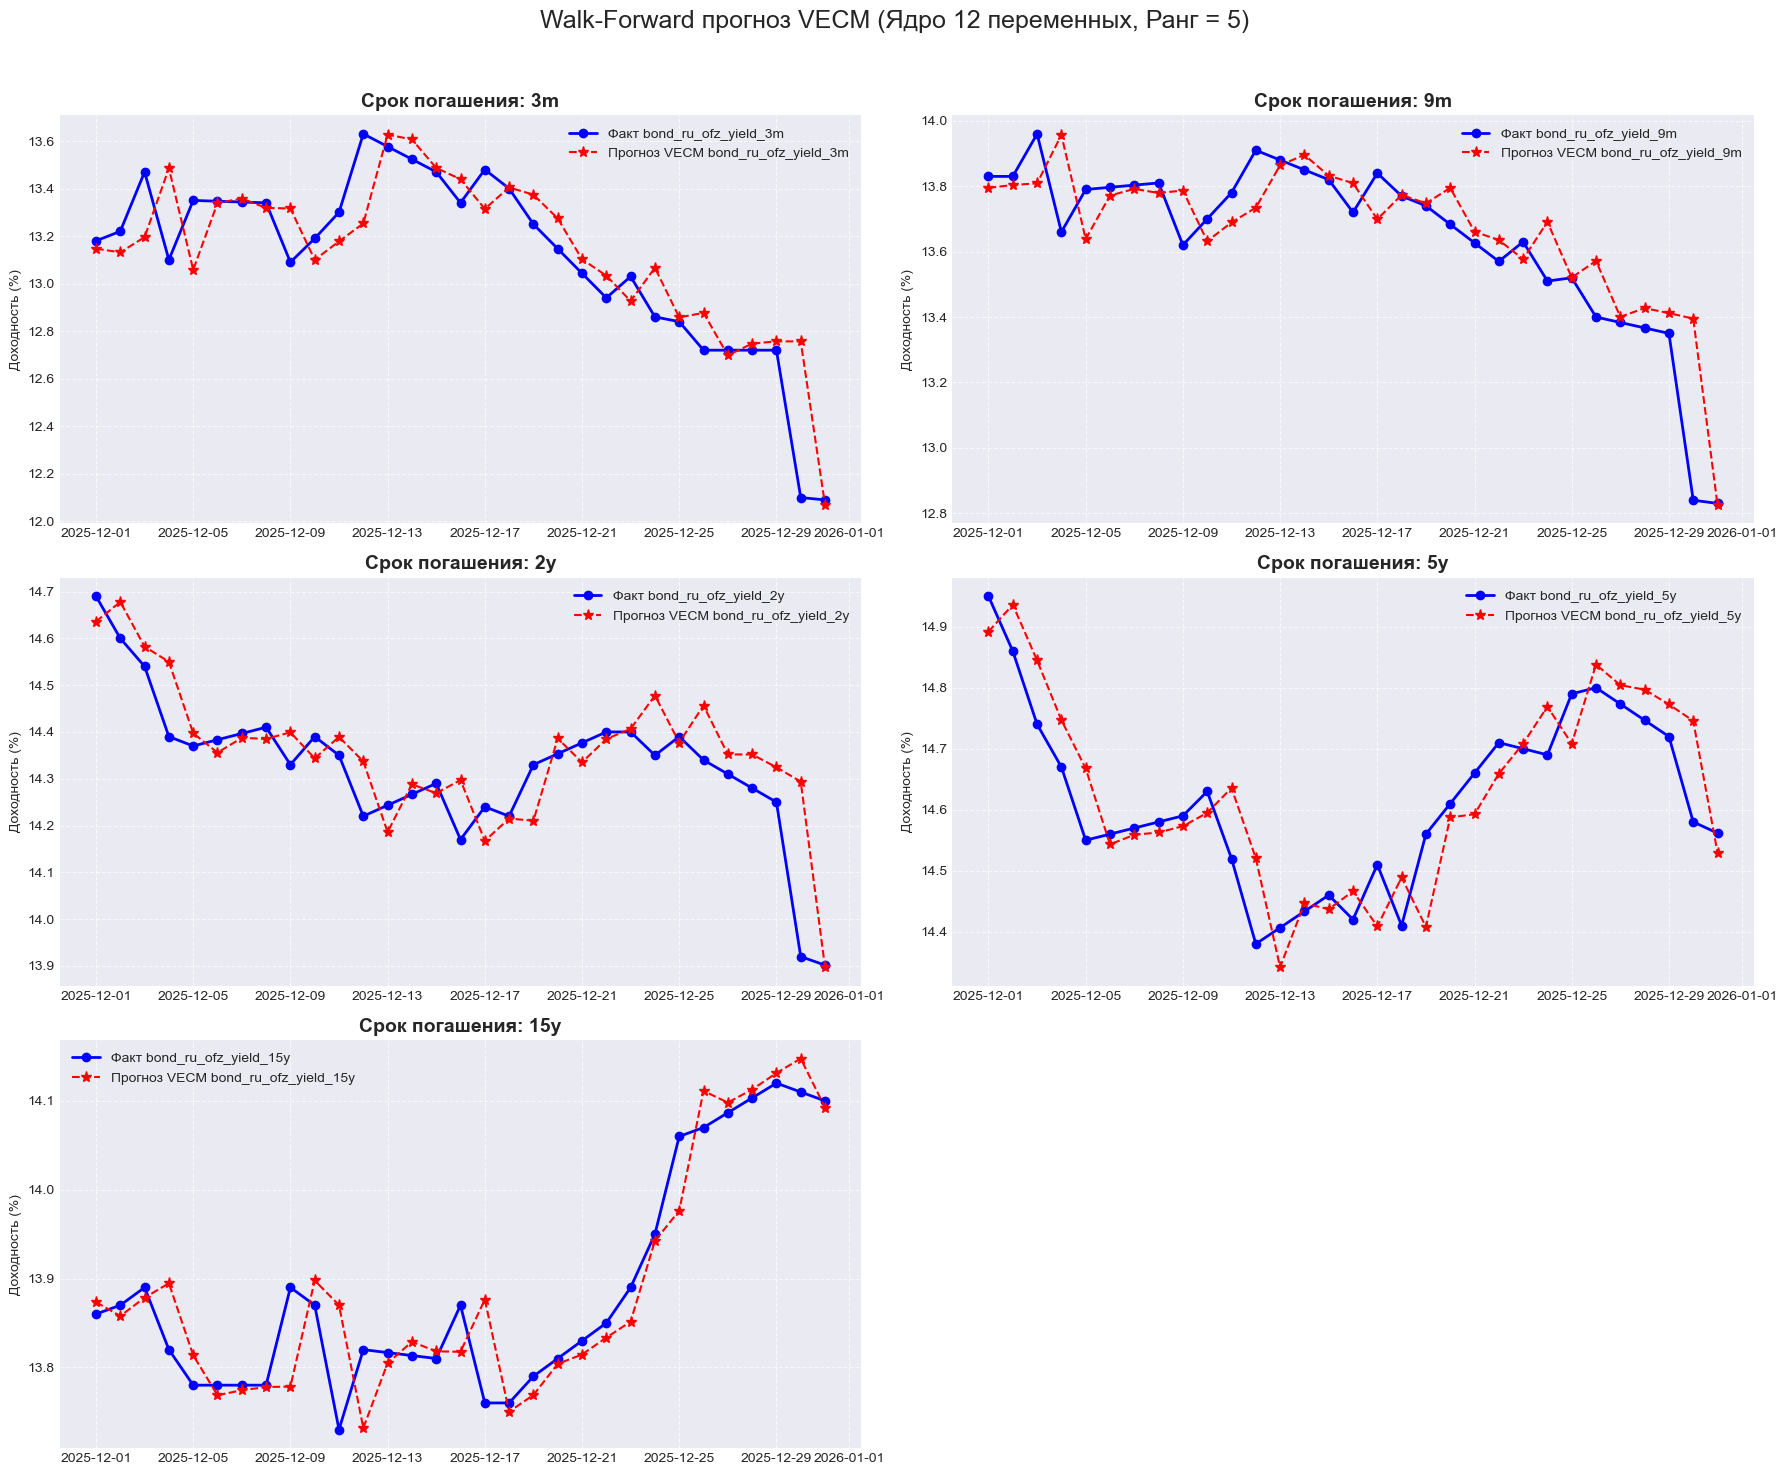

In [54]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(18, 15))
axes = axes.flatten()

for i, tenor in enumerate(ofz_core):
    ax = axes[i]
    ax.plot(df_fact.index, df_fact[tenor], 'bo-', label='Факт ' + tenor, linewidth=2)
    ax.plot(df_pred.index, df_pred[tenor], 'r*--', label='Прогноз VECM ' + tenor, markersize=8)
    
    short_name = tenor.replace('bond_ru_ofz_yield_', '')
    ax.set_title(f'Срок погашения: {short_name}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Доходность (%)')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc='best')

fig.delaxes(axes[5]) 

plt.suptitle(f"Walk-Forward прогноз VECM (Ядро 12 переменных, Ранг = {coint_rank_use})", fontsize=18, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [55]:
from IPython.display import display

print("=== МАТРИЦА ALPHA ===")

alpha_df = pd.DataFrame(final_vecm_res.alpha, index=vecm_cols).round(4)
alpha_df.columns = [f"Vector_{i+1}" for i in range(coint_rank_use)]
display(alpha_df)

print("\n\n=== МАТРИЦА BETA ===")

beta_df = pd.DataFrame(final_vecm_res.beta, index=vecm_cols).round(4)
beta_df.columns = [f"Vector_{i+1}" for i in range(coint_rank_use)]
display(beta_df)

=== МАТРИЦА ALPHA ===


,Vector_1,Vector_2,Vector_3,Vector_4,Vector_5
bond_ru_ofz_yield_3m,-0.0574,0.0616,-0.0550,0.0436,-0.0526
bond_ru_ofz_yield_9m,0.0179,-0.0531,-0.0128,0.0628,-0.0476
bond_ru_ofz_yield_2y,0.0055,0.0116,-0.0936,0.1126,-0.0531
bond_ru_ofz_yield_5y,-0.0029,0.0033,-0.0273,0.0370,-0.0233
bond_ru_ofz_yield_15y,-0.0217,0.0514,-0.0884,0.0851,-0.0441
bond_ru_corp_yield,-0.0338,0.2446,-0.3192,0.3370,-0.1075
brent_price,-0.1488,0.1689,-0.4024,0.4893,-0.3454
macro_ru_key_rate,-0.0001,-0.0004,0.0001,0.0004,-0.0004
KASE_BMC,0.0165,-0.0214,0.0253,-0.0206,0.0169
macro_ru_ruonia_rate,-0.0022,0.0984,-0.1503,0.1043,-0.0102




=== МАТРИЦА BETA ===


,Vector_1,Vector_2,Vector_3,Vector_4,Vector_5
bond_ru_ofz_yield_3m,1.0000,0.0000,-0.0000,-0.0000,-0.0000
bond_ru_ofz_yield_9m,-0.0000,1.0000,0.0000,0.0000,-0.0000
bond_ru_ofz_yield_2y,-0.0000,-0.0000,1.0000,-0.0000,-0.0000
bond_ru_ofz_yield_5y,0.0000,0.0000,-0.0000,1.0000,-0.0000
bond_ru_ofz_yield_15y,0.0000,0.0000,0.0000,0.0000,1.0000
bond_ru_corp_yield,0.4152,-0.5207,-1.3345,-1.5327,-1.0307
brent_price,0.0779,0.0082,-0.0439,-0.0218,0.0447
macro_ru_key_rate,11.3779,5.2027,-1.4155,-7.5789,-11.4574
KASE_BMC,0.6907,0.2441,-0.1302,-0.7558,-1.7059
macro_ru_ruonia_rate,-12.7338,-5.8133,1.5000,8.0969,12.0956


Расчет функций импульсного отклика (горизонт 30 дней)...


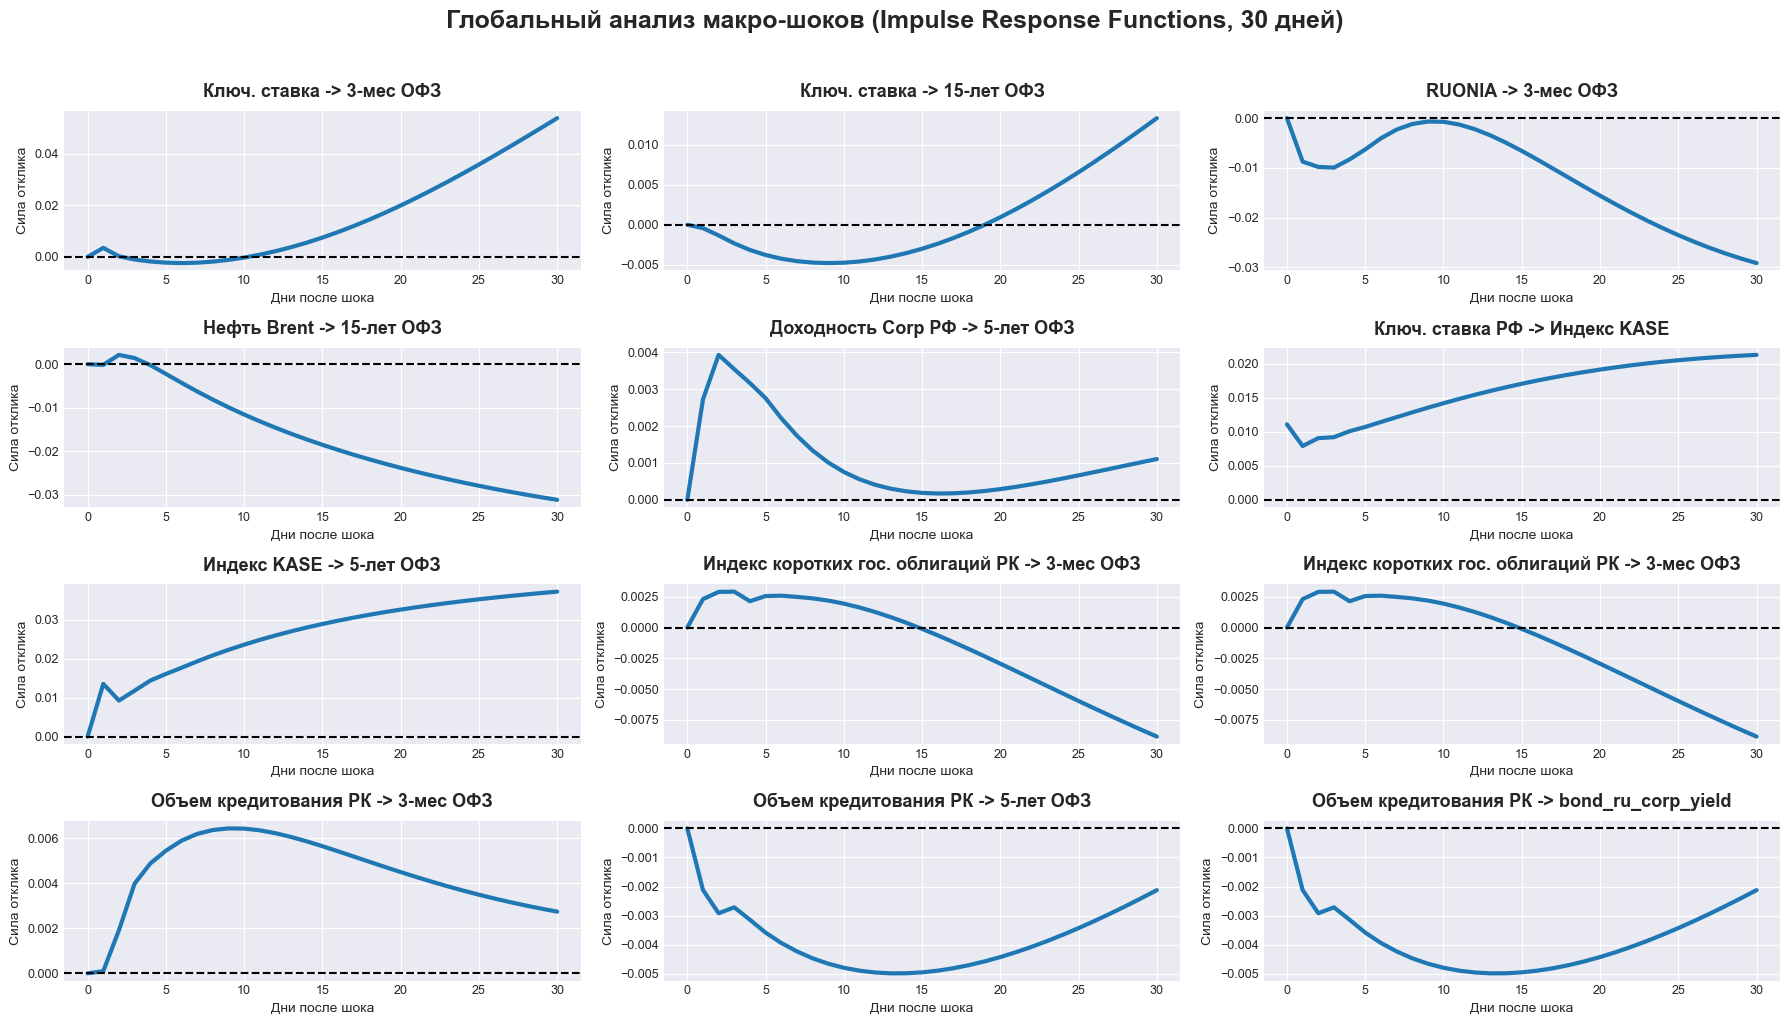

In [56]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')

print("Расчет функций импульсного отклика (горизонт 30 дней)...")
irf = final_vecm_res.irf(periods=30)

var_names = list(final_vecm_res.names)

irf_pairs = [
    ('macro_ru_key_rate', 'bond_ru_ofz_yield_3m', 'Ключ. ставка -> 3-мес ОФЗ'),
    ('macro_ru_key_rate', 'bond_ru_ofz_yield_15y', 'Ключ. ставка -> 15-лет ОФЗ'),
    ('macro_ru_ruonia_rate', 'bond_ru_ofz_yield_3m', 'RUONIA -> 3-мес ОФЗ'),
    ('brent_price', 'bond_ru_ofz_yield_15y', 'Нефть Brent -> 15-лет ОФЗ'),
    ('bond_ru_corp_yield', 'bond_ru_ofz_yield_5y', 'Доходность Corp РФ -> 5-лет ОФЗ'),
    ('macro_ru_key_rate', 'KASE_BMC', 'Ключ. ставка РФ -> Индекс KASE'),
    ('KASE_BMC', 'bond_ru_ofz_yield_5y', 'Индекс KASE -> 5-лет ОФЗ'),
    ('bond_kz_govt_cp_short_u1y', 'bond_ru_ofz_yield_3m', 'Индекс коротких гос. облигаций РК -> 3-мес ОФЗ'),
    ('bond_kz_govt_cp_short_u1y', 'bond_ru_ofz_yield_3m', 'Индекс коротких гос. облигаций РК -> 3-мес ОФЗ'),
    ('loans_kz_total_ln', 'bond_ru_ofz_yield_3m', 'Объем кредитования РК -> 3-мес ОФЗ'), 
    ('loans_kz_total_ln', 'bond_ru_ofz_yield_5y', 'Объем кредитования РК -> 5-лет ОФЗ'),
    ('loans_kz_total_ln', 'bond_ru_ofz_yield_5y', 'Объем кредитования РК -> bond_ru_corp_yield'),   
]

fig, axes = plt.subplots(4, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (impulse_var, response_var, title) in enumerate(irf_pairs):
    ax = axes[idx]
    
    try:
        imp_idx = var_names.index(impulse_var)
        res_idx = var_names.index(response_var)

        if hasattr(irf, 'orth_irfs') and irf.orth_irfs is not None:
            y_vals = irf.orth_irfs[:, res_idx, imp_idx]
        else:
            y_vals = irf.irfs[:, res_idx, imp_idx]
            
        x_vals = np.arange(len(y_vals))
        
        ax.plot(x_vals, y_vals, color='#1f77b4', linewidth=3)
        ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
        
        ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
        ax.set_xlabel("Дни после шока", fontsize=10)
        ax.set_ylabel("Сила отклика", fontsize=10)
        ax.tick_params(axis='both', which='major', labelsize=9)
        
    except ValueError:
        ax.set_title(f"Ошибка: переменная не найдена\n{impulse_var} -> {response_var}", color='red', fontsize=10)

plt.suptitle('Глобальный анализ макро-шоков (Impulse Response Functions, 30 дней)', fontsize=18, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

# То же самое, но без кредитов - слишком шумные

In [57]:
from statsmodels.tsa.vector_ar.vecm import select_order, coint_johansen, VECM
import warnings
from Метрики.read_functions import dict_func

ofz_core = [
    'bond_ru_ofz_yield_3m', 
    'bond_ru_ofz_yield_9m', 
    'bond_ru_ofz_yield_2y', 
    'bond_ru_ofz_yield_5y', 
    'bond_ru_ofz_yield_10y',
    'bond_ru_ofz_yield_20y'
]

macro_anchors = [
    'bond_ru_corp_yield',
    'brent_price',
    'macro_ru_key_rate',
    'KASE_BMC',
    'macro_ru_ruonia_rate',
    'bond_kz_govt_cp_short_u1y',
]

vecm_cols = ofz_core + macro_anchors
df_vecm_slim = df_raw[vecm_cols].dropna()

print(f"Размерность данных для VECM: {df_vecm_slim.shape}")
print("\n--- Тест Йохансена для 12 переменных ---")
lag_order_slim = select_order(df_vecm_slim, maxlags=3, deterministic="ci")
opt_lag_slim = lag_order_slim.aic
print(f"Оптимальный лаг (AIC): {opt_lag_slim}")

johansen_slim = coint_johansen(df_vecm_slim, det_order=1, k_ar_diff=opt_lag_slim)
print("Тест Йохансена прошел успешно. Ищем ранг коинтеграции (r):")

cointegration_rank = 0
for i in range(len(johansen_slim.lr1)):
    trace_stat = johansen_slim.lr1[i]
    crit_val_95 = johansen_slim.cvt[i, 1]
    
    if trace_stat > crit_val_95:
         cointegration_rank = i + 1
    else:
        print(f"Ранг r <= {i} : Trace Stat = {trace_stat:.2f} , Crit(95%) = {crit_val_95:.2f} -> НЕ ОТВЕРГАЕМ H0")
        break
        
print(f"Выбранный ранг коинтеграции: {cointegration_rank}")

Размерность данных для VECM: (1462, 12)

--- Тест Йохансена для 12 переменных ---
Оптимальный лаг (AIC): 2
Тест Йохансена прошел успешно. Ищем ранг коинтеграции (r):
Ранг r <= 6 : Trace Stat = 98.54 , Crit(95%) = 107.34 -> НЕ ОТВЕРГАЕМ H0
Выбранный ранг коинтеграции: 6


In [58]:
import joblib
import numpy as np
import pandas as pd
from statsmodels.tsa.vector_ar.vecm import VECM

ofz_core = [
    'bond_ru_ofz_yield_3m', 'bond_ru_ofz_yield_9m', 'bond_ru_ofz_yield_2y', 
    'bond_ru_ofz_yield_5y', 'bond_ru_ofz_yield_10y', 'bond_ru_ofz_yield_20y'
]
macro_anchors = [
    'bond_ru_corp_yield', 'brent_price', 'macro_ru_key_rate', 'KASE_BMC', 
    'macro_ru_ruonia_rate', 'bond_kz_govt_cp_short_u1y'
]
vecm_cols = ofz_core + macro_anchors
df_vecm_slim = df_raw[vecm_cols].dropna()

# Гиперпараметры из теста Йохансена
opt_lag_slim = 2
coint_rank_use = 6

# Подготовка к Walk-Forward
train_end = pd.to_datetime('2025-11-30')
history_df = df_vecm_slim.loc[:train_end].copy()
test_df = df_vecm_slim.loc['2025-12-01':'2025-12-31']

predictions = []
actuals = []

print(f"Запуск Walk-Forward Validation (1 день вперед). Ранг коинтеграции: {coint_rank_use}...")

for date, row in test_df.iterrows():
    vecm_model = VECM(history_df, k_ar_diff=opt_lag_slim, coint_rank=coint_rank_use, deterministic="ci")
    try:
        vecm_res = vecm_model.fit()
        forecast_levels = vecm_res.predict(steps=1)
        predictions.append(forecast_levels[0][:len(ofz_core)]) # Берем только ОФЗ
    except Exception as e:
        predictions.append(history_df[ofz_core].iloc[-1].values)
        
    actuals.append(row[ofz_core].values)
    history_df = pd.concat([history_df, pd.DataFrame(row).T])

# Обучение финальной модели на всей истории и сохранение
final_vecm_model = VECM(history_df, k_ar_diff=opt_lag_slim, coint_rank=coint_rank_use, deterministic="ci")
final_vecm_res = final_vecm_model.fit()
joblib.dump(final_vecm_res, 'vecm_ofz_model.pkl')
print("\nФинальная VECM-модель успешно сохранена в 'vecm_ofz_model.pkl'")

# Расчет MAE
df_pred = pd.DataFrame(predictions, index=test_df.index, columns=ofz_core)
df_fact = pd.DataFrame(actuals, index=test_df.index, columns=ofz_core)

mae_per_tenor = np.abs(df_pred - df_fact).mean()
overall_mae = mae_per_tenor.mean()

print(f"\nСредняя абсолютная ошибка (MAE) 1-дневных прогнозов: {overall_mae:.4f} п.п.")
print(mae_per_tenor.round(4))

Запуск Walk-Forward Validation (1 день вперед). Ранг коинтеграции: 6...

Финальная VECM-модель успешно сохранена в 'vecm_ofz_model.pkl'

Средняя абсолютная ошибка (MAE) 1-дневных прогнозов: 0.0711 п.п.
bond_ru_ofz_yield_3m     0.1292
bond_ru_ofz_yield_9m     0.0909
bond_ru_ofz_yield_2y     0.0674
bond_ru_ofz_yield_5y     0.0664
bond_ru_ofz_yield_10y    0.0342
bond_ru_ofz_yield_20y    0.0383
dtype: float64


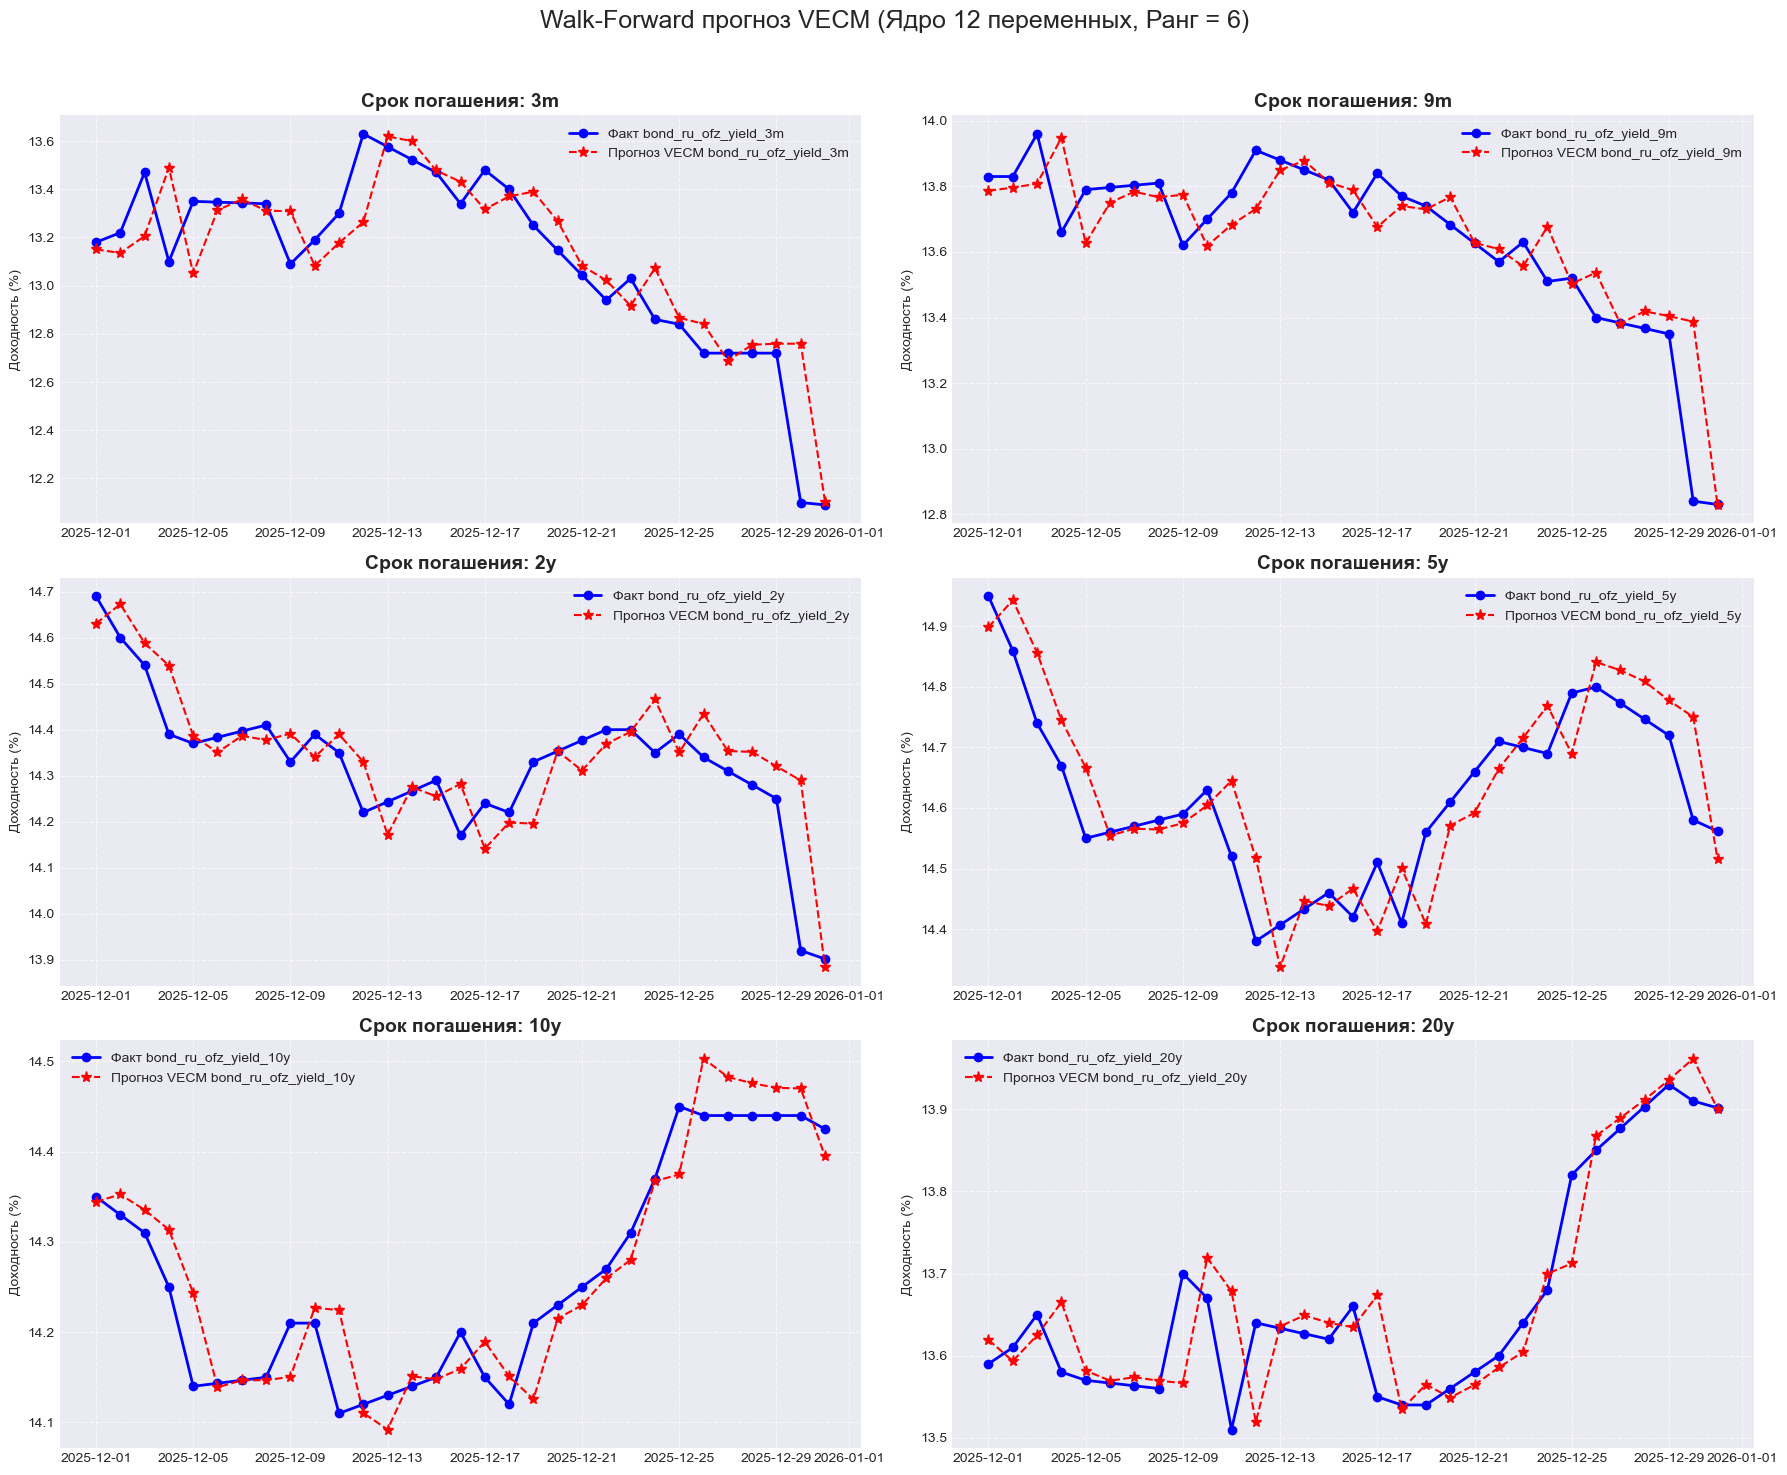

In [59]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(18, 15))
axes = axes.flatten()

for i, tenor in enumerate(ofz_core):
    ax = axes[i]
    ax.plot(df_fact.index, df_fact[tenor], 'bo-', label='Факт ' + tenor, linewidth=2)
    ax.plot(df_pred.index, df_pred[tenor], 'r*--', label='Прогноз VECM ' + tenor, markersize=8)
    
    short_name = tenor.replace('bond_ru_ofz_yield_', '')
    ax.set_title(f'Срок погашения: {short_name}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Доходность (%)')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc='best')

plt.suptitle(f"Walk-Forward прогноз VECM (Ядро 12 переменных, Ранг = {coint_rank_use})", fontsize=18, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [60]:
from IPython.display import display

print("=== МАТРИЦА ALPHA ===")

alpha_df = pd.DataFrame(final_vecm_res.alpha, index=vecm_cols).round(4)
alpha_df.columns = [f"Vector_{i+1}" for i in range(coint_rank_use)]
display(alpha_df)

print("\n\n=== МАТРИЦА BETA ===")

beta_df = pd.DataFrame(final_vecm_res.beta, index=vecm_cols).round(4)
beta_df.columns = [f"Vector_{i+1}" for i in range(coint_rank_use)]
display(beta_df)

=== МАТРИЦА ALPHA ===


,Vector_1,Vector_2,Vector_3,Vector_4,Vector_5,Vector_6
bond_ru_ofz_yield_3m,-0.0461,0.0478,-0.0844,0.1150,-0.0712,-0.0182
bond_ru_ofz_yield_9m,0.0130,-0.0436,-0.0727,0.2341,-0.2346,0.0792
bond_ru_ofz_yield_2y,-0.0092,0.0432,-0.1617,0.2824,-0.2494,0.0805
bond_ru_ofz_yield_5y,-0.0170,0.0520,-0.1086,0.1534,-0.1217,0.0291
bond_ru_ofz_yield_10y,-0.0284,0.0797,-0.1392,0.1795,-0.1356,0.0281
bond_ru_ofz_yield_20y,-0.0457,0.1062,-0.1411,0.1448,-0.0897,0.0006
bond_ru_corp_yield,-0.0178,0.0680,-0.0368,0.0555,0.1041,-0.0128
brent_price,-0.1981,0.3525,-0.8818,1.4461,-1.2107,0.2825
macro_ru_key_rate,-0.0003,0.0003,-0.0002,0.0008,-0.0012,-0.0000
KASE_BMC,0.0269,-0.0715,0.1104,-0.1283,0.0966,-0.0194




=== МАТРИЦА BETA ===


,Vector_1,Vector_2,Vector_3,Vector_4,Vector_5,Vector_6
bond_ru_ofz_yield_3m,1.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000
bond_ru_ofz_yield_9m,-0.0000,1.0000,0.0000,-0.0000,0.0000,-0.0000
bond_ru_ofz_yield_2y,0.0000,0.0000,1.0000,0.0000,-0.0000,-0.0000
bond_ru_ofz_yield_5y,0.0000,0.0000,0.0000,1.0000,0.0000,-0.0000
bond_ru_ofz_yield_10y,-0.0000,-0.0000,-0.0000,0.0000,1.0000,0.0000
bond_ru_ofz_yield_20y,0.0000,-0.0000,0.0000,-0.0000,0.0000,1.0000
bond_ru_corp_yield,-0.2335,-0.9092,-1.2911,-1.0451,-0.5992,-0.2880
brent_price,0.0658,-0.0053,-0.0556,-0.0264,0.0259,0.0594
macro_ru_key_rate,0.8685,-1.0632,-1.2029,0.1269,0.3381,-0.9853
KASE_BMC,-0.6175,-0.5113,-0.1775,0.1933,0.0947,-0.2453


Расчет функций импульсного отклика (горизонт 30 дней)...


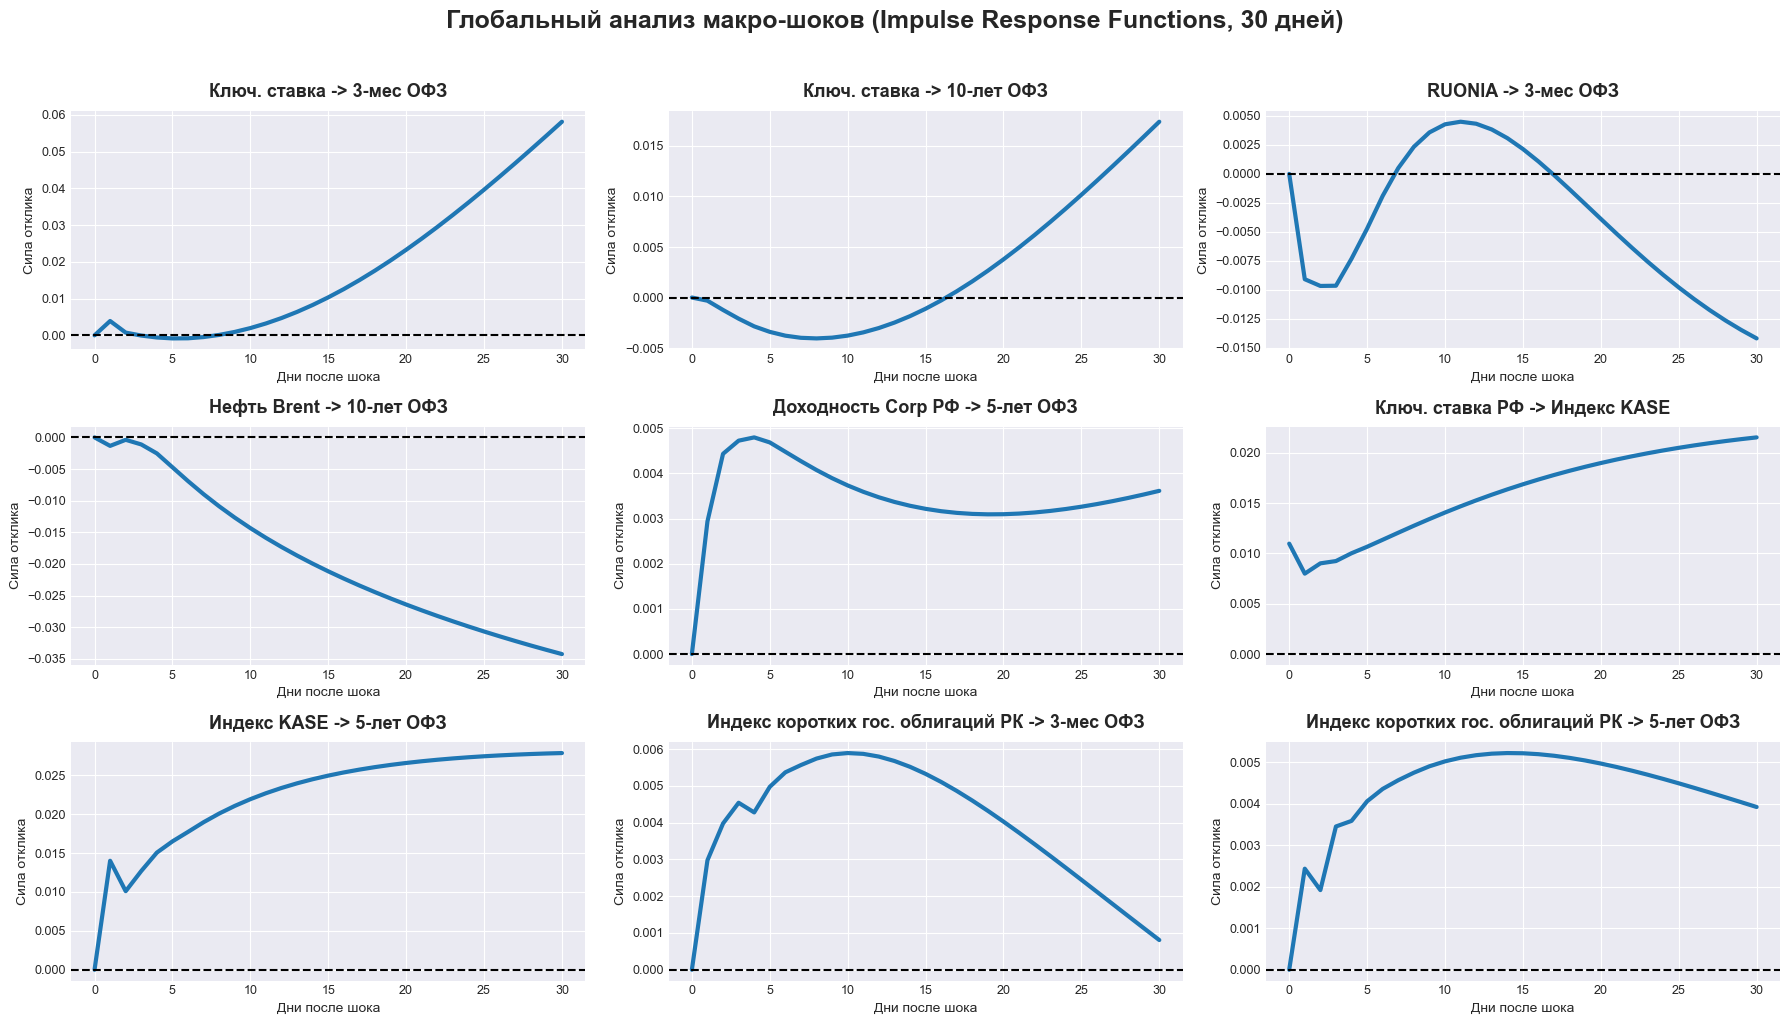

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')

print("Расчет функций импульсного отклика (горизонт 30 дней)")
irf = final_vecm_res.irf(periods=30)

var_names = list(final_vecm_res.names)

irf_pairs = [
    ('macro_ru_key_rate', 'bond_ru_ofz_yield_3m', 'Ключ. ставка -> 3-мес ОФЗ'),
    ('macro_ru_key_rate', 'bond_ru_ofz_yield_10y', 'Ключ. ставка -> 10-лет ОФЗ'),
    ('macro_ru_ruonia_rate', 'bond_ru_ofz_yield_3m', 'RUONIA -> 3-мес ОФЗ'),
    ('brent_price', 'bond_ru_ofz_yield_10y', 'Нефть Brent -> 10-лет ОФЗ'),
    ('bond_ru_corp_yield', 'bond_ru_ofz_yield_5y', 'Доходность Corp РФ -> 5-лет ОФЗ'),
    ('macro_ru_key_rate', 'KASE_BMC', 'Ключ. ставка РФ -> Индекс KASE'),
    ('KASE_BMC', 'bond_ru_ofz_yield_5y', 'Индекс KASE -> 5-лет ОФЗ'),
    ('bond_kz_govt_cp_short_u1y', 'bond_ru_ofz_yield_3m', 'Индекс коротких гос. облигаций РК -> 3-мес ОФЗ'),
    ('bond_kz_govt_cp_short_u1y', 'bond_ru_ofz_yield_5y', 'Индекс коротких гос. облигаций РК -> 5-лет ОФЗ'),   
]

fig, axes = plt.subplots(3, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (impulse_var, response_var, title) in enumerate(irf_pairs):
    ax = axes[idx]
    
    try:
        imp_idx = var_names.index(impulse_var)
        res_idx = var_names.index(response_var)

        if hasattr(irf, 'orth_irfs') and irf.orth_irfs is not None:
            y_vals = irf.orth_irfs[:, res_idx, imp_idx]
        else:
            y_vals = irf.irfs[:, res_idx, imp_idx]
            
        x_vals = np.arange(len(y_vals))
        
        ax.plot(x_vals, y_vals, color='#1f77b4', linewidth=3)
        ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
        
        ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
        ax.set_xlabel("Дни после шока", fontsize=10)
        ax.set_ylabel("Сила отклика", fontsize=10)
        ax.tick_params(axis='both', which='major', labelsize=9)
        
    except ValueError:
        ax.set_title(f"Ошибка: переменная не найдена\n{impulse_var} -> {response_var}", color='red', fontsize=10)

plt.suptitle('Глобальный анализ макро-шоков (Impulse Response Functions, 30 дней)', fontsize=18, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()